# Al electron-phonon coupling and $\alpha^2F(\omega)$ — native, EPW-free

**Goal**: read `ph.x`'s raw coarse-grid DFPT output directly and Wannier-interpolate the electron-phonon coupling entirely inside waw — the same problem EPW solves, without needing EPW ("very difficult to use, and requires massive amounts of memory"). New modules: `interfaces.quantum_espresso.dvscf_io` (raw potential-variation reader) and `analysis.elph` (Bloch matrix element, double real-space Wannier transform, $\alpha^2F(\omega)$).

**Why not `ph.x`'s own `electron_phonon='Wannier'`?** That legacy (Calandra-Mauri-era) feature writes electron-phonon matrix elements directly, but crashes with a heap-corruption error in this QE version (`double free or corruption (!prev)`, confirmed reproducible both serial and parallel, inside `ep_matrix_element_wannier.f90`'s own dvscf-reading loop). EPW itself does not drive that codepath either — its real workflow is a **plain** phonon DFPT run (`trans=.true.`, `fildvscf` set, no `electron_phonon`/`dvscf_star` needed) producing the raw self-consistent-potential variation, from which the coupling matrix elements are built directly. This notebook does exactly that.

**The perturbation has three pieces, and `dvscf` is only one of them.** QE's `fildvscf` output is the INDUCED self-consistent response alone (Hartree + xc reaction of the valence density); the BARE ionic perturbation — the local-pseudopotential gradient $-\nabla V_\mathrm{loc}$ (`analysis.elph.bare_local_dv`) and the nonlocal Kleinman-Bylander derivative (`analysis.elph.KleinmanBylanderPerturbation`), both reconstructed from the UPF file itself — must be added on top, exactly as QE's own `dvqpsi_us.f90` does. Al is the worst-case material for omitting them: the textbook local/nonlocal cancellation in simple metals collapses the transverse coupling from $\sim$530 to the true $\sim$19 meV only once the nonlocal term is in. With all three terms the matrix elements reproduce a REAL EPW run (`prtgkk=.true.`, identical inputs) to 1–5%; the residual is ordinary reconstruction error (grid, KB, `ph.x` convergence). (The NLCC core-correction xc term is *not* missing — QE already folds it into the induced `dvscf` via `dv_of_drho(drho, drhoc)`, so reading `dvscf` already includes it; adding it again double-counts.)

**Meshes: electron k denser than phonon q.** The electron and phonon meshes need NOT match — only that the (coarser) phonon q-mesh divides the (finer) electron k-mesh component-wise, so every q coincides exactly with a k-mesh point. Here: $12\times12\times12$ electron k, $6\times6\times6$ phonon q (and $6\times2=12$), $\texttt{ecutwfc}=52$ Ry.

**Material**: bulk fcc aluminium, $a=4.0495\,$Å, a textbook simple metal with a well-known experimental electron-phonon mass enhancement $\lambda\approx0.4$ (e.g. McMillan, *Phys. Rev.* **167**, 331 (1968)). The direct cross-validation targets are real EPW runs with identical SCF/phonon inputs: $\lambda=0.499$ (6³ coarse k) and $\lambda=0.368$ (12³ coarse k), both with fine 40³/40³ interpolation meshes.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Crystal setup — why `ibrav=2`, not this project's usual `ibrav=0`

Every other notebook in this project uses `ibrav=0` (explicit `CELL_PARAMETERS`, this project's own universal convention). For `ph.x` specifically this caused a real problem here: a finite-precision, generic `CELL_PARAMETERS` card made `ph.x`'s symmetry finder miss point-group operations it should find, blowing up the number of k-points `ph.x` needs per q-point by ~38x. Switching to an explicit `ibrav=2` (fcc) + `celldm(1)` — letting QE construct the cell **analytically** instead of from rounded decimals — fixed it immediately (confirmed: 48 symmetry operations found, the full $O_h$ point group). The catch: `atoms.get_cell()` must then be built to EXACTLY match QE's own `ibrav=2` primitive-vector convention (not just the same lattice up to a rotation), since `recip_lattice`/`real_lattice` and the `.nnkp` b-vectors all read `atoms.get_cell()` directly. `write_pw_input` now supports this (an explicit `ibrav` in `system` skips the `CELL_PARAMETERS` card).

In [2]:
from ase import Atoms
from waw.interfaces.projections import spd_projections
from waw.interfaces.ase.structure import monkhorst_pack, real_lattice as real_lattice_fn, recip_lattice, band_path
from waw.interfaces.quantum_espresso.io import (
    write_pw_input, write_ph_input, write_ph_input_explicit_q, run_pw, read_bands_eigenvalues,
)
from waw.interfaces.quantum_espresso.phonon_io import read_force_constants, read_ph_frequencies
from waw.interfaces.quantum_espresso import dvscf_io
from waw.interfaces.quantum_espresso.upf import read_norm_conserving
from waw.interfaces.wannier90.io import read_unk
from waw.analysis import elph
from waw.analysis.dos import density_of_states
from waw.analysis.phonon import apply_acoustic_sum_rule, interpolate_phonons
from waw.analysis.wigner_transport import velocity_matrix
from waw.core.hamiltonian import interpolate_bands
from waw.units import CM1_TO_HARTREE
import torch

A_ANG = 4.0495
A_BOHR = A_ANG / BOHR_TO_ANG
cell = A_ANG * np.array([[-0.5, 0.0, 0.5], [0.0, 0.5, 0.5], [-0.5, 0.5, 0.0]])   # QE's own ibrav=2 vectors
atoms = Atoms('Al', scaled_positions=[[0.0, 0.0, 0.0]], cell=cell, pbc=True)
K_MESH = (12, 12, 12)   # electron mesh
Q_MESH = (6, 6, 6)      # phonon mesh -- divides K_MESH component-wise (12 = 6*2)
ECUTWFC = 52.0
QE_IBRAV = {'ibrav': 2, 'celldm(1)': A_BOHR}
WORK = HERE / 'runs' / 'al_elph_alpha2f'
WORK.mkdir(parents=True, exist_ok=True)

projections = spd_projections((0.0, 0.0, 0.0), 's;p')   # 4 MLWFs: minimal sp basis, 1 Al atom
NUM_WANN = len(projections)
NBND = 12
real_lat = real_lattice_fn(atoms)

# bare-perturbation ingredients (see intro): the UPF's own radial data
PSEUDOS = [read_norm_conserving(PSEUDO_DIR / 'Al.upf')]
TAU_FRAC = np.zeros((1, 3))
TYPES = np.array([0])
ECUT_RHO = 2.0 * ECUTWFC   # Hartree: ecutrho = 4*ecutwfc, QE Ry input -> 2x in Ha

### 2. Electron Wannierisation (`write_unk=True`)

Same recipe as the other Al notebook, plus `write_unk=True`: the electron-phonon matrix element needs the periodic Bloch parts $u_{n\mathbf k}(\mathbf r)$ on the real-space FFT grid (pw2wannier90's `UNK` files, already used elsewhere in this project for plotting MLWFs) at every coarse mesh k-point.

In [3]:
ov = qe.generate_overlaps(
    atoms, K_MESH, WORK, 'al',
    ecutwfc=ECUTWFC, scf_kpts=K_MESH, nbnd=NBND, num_wann=NUM_WANN,
    projections=projections,
    system_extra=dict(occupations='smearing', smearing='mp', degauss=0.02, **QE_IBRAV),
    pseudopotentials={'Al': 'Al.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    write_unk=True,
)
E_FERMI_EV = ov['fermi_energy']
E_FERMI = E_FERMI_EV * EV_TO_HARTREE   # QE's scf Fermi level; the MODEL's own E_F is derived in section 9
kpts = ov['kpts']
print(f"QE scf Fermi = {E_FERMI_EV:.4f} eV = {E_FERMI:.6f} Ha")

# The MLWF minimisation is cached (waw.save_wannier_result stores hr, centres
# AND the gauge V/U_final that the el-ph Wannier transform in section 7
# needs); delete the .npz to re-minimise. Everything downstream -- g(Re,Rq)
# included -- is tied to THIS gauge, so the g_R cache in section 7 must be
# deleted together with this one.
WANN_CACHE = WORK / 'al_wannier_result.npz'
if WANN_CACHE.exists():
    result = waw.load_wannier_result(WANN_CACHE)
    print('loaded cached MLWF result')
else:
    result = wannierize(
        atoms, K_MESH, kpts,
        mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
        nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=NUM_WANN,
        outer_window=(-1e3, 1e3), frozen_window=(E_FERMI_EV - 2.0, E_FERMI_EV + 2.0),
        guiding_centres=True, optimizer='cg',
        n_restarts=2, dis_n_iter=2000, n_iter=2000, verbose=False,
    )
    waw.save_wannier_result(result, WANN_CACHE)
print(f"Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2")

hr = result.hr
eig, U = elph.band_eigensystem(hr, kpts)   # band eigenvalues (Hartree) + gauge at the coarse mesh
print('band eig range (eV):', eig.min() * HARTREE_TO_EV, eig.max() * HARTREE_TO_EV)

QE scf Fermi = 7.7436 eV = 0.284572 Ha


loaded cached MLWF result
Omega_total = 6.2354 Ang^2
band eig range (eV): -3.2268423159088626 24.042189600961844


### 3. Electron bands: DFT vs. Wannier interpolation

The standard wannier90-tutorial validation plot this project had not built yet: an explicit `calculation='bands'` NSCF run along the standard k-path (cheap -- a single Davidson diagonalization per k, no self-consistency), read directly from `pw.x`'s own `bands (ev):` printout (`verbosity='high'` is required -- QE otherwise suppresses this listing beyond 100 k-points), overlaid against `interpolate_bands` on the same path.

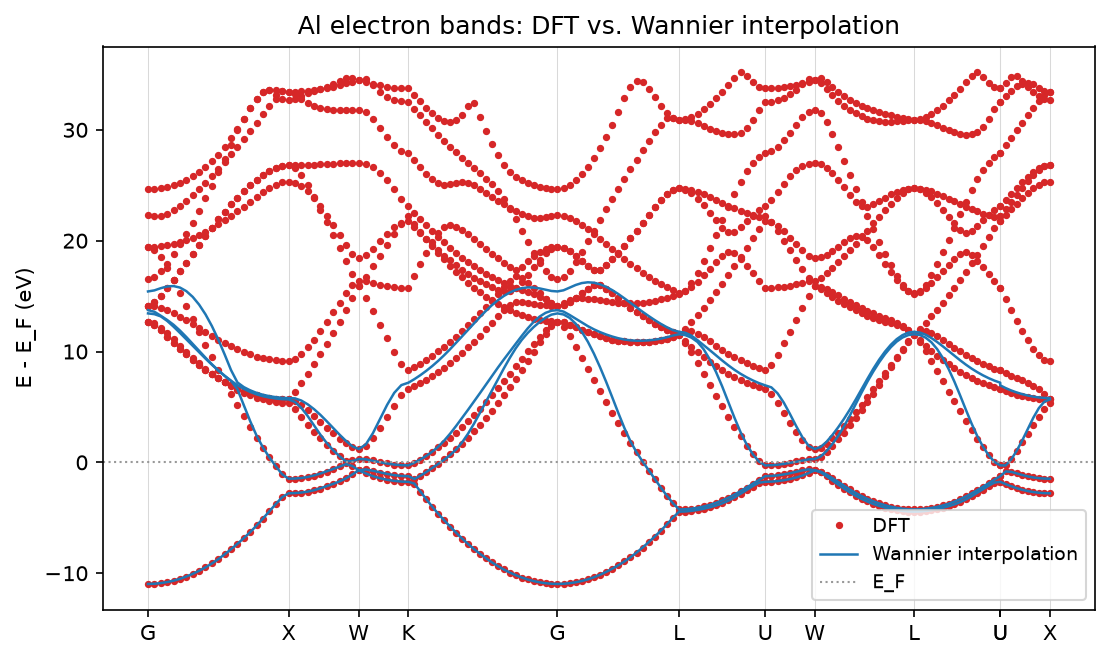

In [4]:
bp = band_path(atoms, npoints=150)
xcoords, xticks, xlabels = bp.get_linear_kpoint_axis()

write_pw_input(
    WORK / 'al.bands.in', atoms,
    control={'calculation': 'bands', 'prefix': 'al', 'outdir': './out',
             'pseudo_dir': str(PSEUDO_DIR), 'verbosity': 'high'},
    system={'ecutwfc': ECUTWFC, 'occupations': 'smearing', 'smearing': 'mp', 'degauss': 0.02,
            'nbnd': NBND, **QE_IBRAV},
    electrons={'conv_thr': 1.0e-8},
    pseudopotentials={'Al': 'Al.upf'}, kpoints=('crystal', bp.kpts),
)
run_pw(WORK / 'al.bands.in', WORK / 'al.bands.out', ncores=NCORES)
dft_bands_ev = read_bands_eigenvalues(WORK / 'al.bands.out', nbnd=NBND)

wann_bands_ev = interpolate_bands(hr, bp.kpts) * HARTREE_TO_EV

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=150)
for ib in range(dft_bands_ev.shape[1]):
    ax.plot(xcoords, dft_bands_ev[:, ib] - E_FERMI_EV, 'o', ms=2.5, color='C3',
           label='DFT' if ib == 0 else None)
for ib in range(wann_bands_ev.shape[1]):
    ax.plot(xcoords, wann_bands_ev[:, ib] - E_FERMI_EV, '-', lw=1.2, color='C0',
           label='Wannier interpolation' if ib == 0 else None)
ax.axhline(0.0, color='0.6', ls=':', lw=1, label='E_F')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels)
for x in xticks:
    ax.axvline(x, color='0.85', lw=0.5, zorder=0)
ax.set_ylabel('E - E_F (eV)'); ax.set_title('Al electron bands: DFT vs. Wannier interpolation')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

### 4. Phonons: standard `ph.x` (16 irreducible q) + `q2r.x`

The dynamical matrix / force constants use the ordinary, cheap `ldisp=.true.` route (symmetry-reduced to the irreducible wedge) -- `q2r.x` already handles the star-of-q symmetry unfolding correctly for the dynamical matrix specifically, so nothing new is needed for phonons alone.

In [5]:
if not (WORK / 'al.fc').exists():
    scf_system = {'ecutwfc': ECUTWFC, 'occupations': 'smearing', 'smearing': 'mp', 'degauss': 0.02, **QE_IBRAV}
    write_pw_input(
        WORK / 'al.ph_scf.in', atoms,
        control={'calculation': 'scf', 'prefix': 'al', 'outdir': './out_ph', 'pseudo_dir': str(PSEUDO_DIR)},
        system=scf_system, electrons={'conv_thr': 1.0e-10},
        pseudopotentials={'Al': 'Al.upf'}, kpoints=('automatic', Q_MESH, (0, 0, 0)),
    )
    run_pw(WORK / 'al.ph_scf.in', WORK / 'al.ph_scf.out', ncores=NCORES)
    write_ph_input(
        WORK / 'al.ph1.in', prefix='al', outdir='./out_ph', fildyn='al.elph.dyn',
        nq=Q_MESH, tr2_ph=1.0e-14, extra={'fildvscf': 'dvscf'},
    )
    run_pw(WORK / 'al.ph1.in', WORK / 'al.ph1.out', ncores=NCORES, pw='ph.x')
    from waw.interfaces.quantum_espresso.io import write_q2r_input
    write_q2r_input(WORK / 'al.q2r.in', fildyn='al.elph.dyn', flfrc='al.fc', zasr='crystal')
    run_pw(WORK / 'al.q2r.in', WORK / 'al.q2r.out', ncores=1, pw='q2r.x')
print('al.fc ready:', (WORK / 'al.fc').exists())

fc_data = read_force_constants(WORK / 'al.fc')
fc_data = apply_acoustic_sum_rule(fc_data)   # dynamical-matrix ASR (a DIFFERENT correction from section 7 below)
masses_amu, types = fc_data['masses_amu'], fc_data['types']

al.fc ready: True


### 5. Phonon bands: DFT (fresh DFPT along the path) vs. force-constant interpolation

The phonon analogue of section 3: a sparse set of q-points along the SAME standard path, each a genuine, independent DFPT calculation (`ph.x`'s own per-q `freq (...) [cm-1]` printout, reusing the explicit-q-list machinery from section 6 below), compared against the force-constant Fourier interpolation (`interpolate_phonons`) along a dense sampling of the same path -- this is a genuine check of `q2r.x`'s real-space-truncation interpolation error, not just a trivial identity (unlike evaluating the interpolation exactly AT the original coarse q-mesh points, which is guaranteed to match by construction).

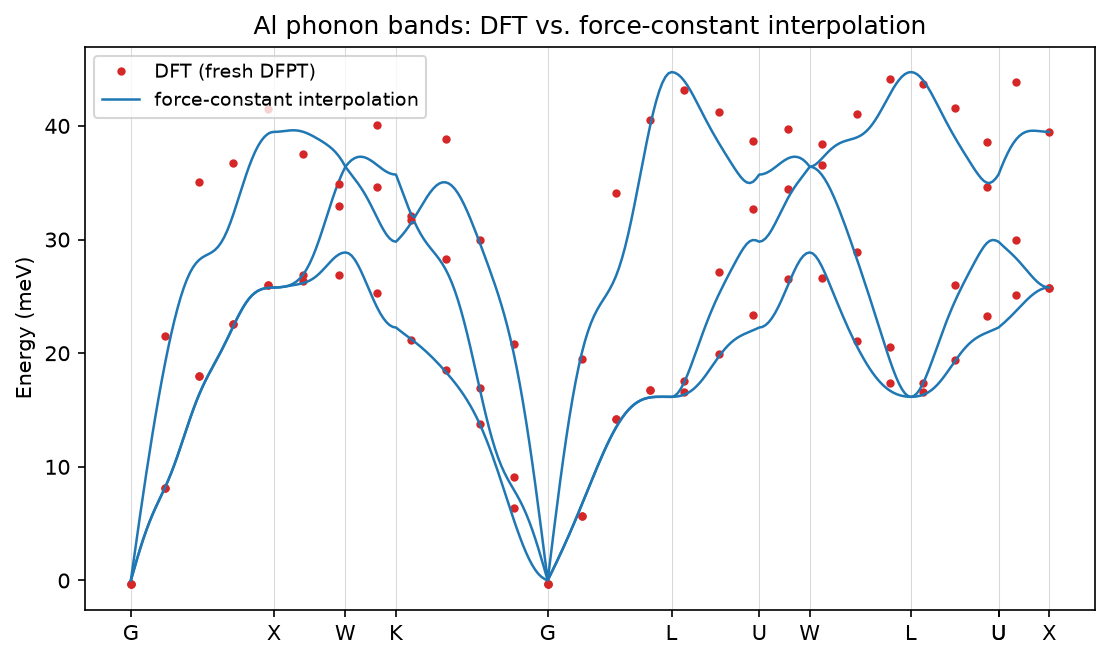

In [6]:
# ONE band path for both curves: the DFT q-points are an exact SUBSET of the
# dense interpolation path, so the two share identical linear-axis coordinates
# and ticks. (ASE's band_path distributes a fixed npoints across the segments,
# so band_path(28) and band_path(300) do NOT sample the same points and yield
# different get_linear_kpoint_axis() lengths -- they must not be mixed.)
bp_ph = band_path(atoms, npoints=300)
xcoords_ph, xticks_ph, xlabels_ph = bp_ph.get_linear_kpoint_axis()
sparse_idx = np.unique(np.linspace(0, len(bp_ph.kpts) - 1, 28).round().astype(int))
q_frac_sparse = bp_ph.kpts[sparse_idx]
q_tpiba_path = q_frac_sparse @ recip_lattice(atoms) * A_BOHR / (2 * np.pi)
write_ph_input_explicit_q(
    WORK / 'al.ph_path.in', prefix='al', outdir='./out_ph', fildyn='al.path.dyn',
    qpoints_tpiba=q_tpiba_path, tr2_ph=1.0e-12, extra={},
)
run_pw(WORK / 'al.ph_path.in', WORK / 'al.ph_path.out', ncores=NCORES, pw='ph.x')
dft_freq_cm1 = read_ph_frequencies(WORK / 'al.ph_path.out', n_modes=3)
xcoords_ph_sparse = xcoords_ph[sparse_idx]

bands_ph = interpolate_phonons(fc_data, real_lat, np.zeros((1, 3)), bp_ph.kpts)

CM1_TO_MEV = 0.1239841984
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=150)
for m in range(3):
    ax.plot(xcoords_ph_sparse, dft_freq_cm1[:, m] * CM1_TO_MEV, 'o', ms=3, color='C3',
           label='DFT (fresh DFPT)' if m == 0 else None)
    ax.plot(xcoords_ph, bands_ph.freq_cm1[:, m] * CM1_TO_MEV, '-', lw=1.2, color='C0',
           label='force-constant interpolation' if m == 0 else None)
ax.set_xticks(xticks_ph); ax.set_xticklabels(xlabels_ph)
for x in xticks_ph:
    ax.axvline(x, color='0.85', lw=0.5, zorder=0)
ax.set_ylabel('Energy (meV)'); ax.set_title('Al phonon bands: DFT vs. force-constant interpolation')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

### 6. The FULL, symmetry-unreduced q-grid `dvscf` run

This is the part that's genuinely new. A real double Fourier transform of $g(\mathbf k,\mathbf q)$ to real space needs the potential variation at **every** point of the $6\times6\times6$ phonon mesh (not just the 16 irreducible ones) -- reconstructing the missing points by symmetry is exactly what `dvscf_star` (the crashing codepath) would normally do. Simplest, fully robust alternative for a system this small: just compute all $216$ q-points directly and independently (`qplot=.true., q_in_band_form=.false.`, QE's own docs: "only the list of q points given as input is calculated"). At ~1-2s per q-point for this tiny 1-atom cell, that's a few minutes, not hours -- note this uses the COARSER `Q_MESH`, not `K_MESH`, so its cost is unaffected by how dense the electron mesh is.

In [7]:
if not (WORK / 'out_ph_grid' / '_ph0' / 'al.phsave' / 'patterns.216.xml').exists():
    scf_system = {'ecutwfc': ECUTWFC, 'occupations': 'smearing', 'smearing': 'mp', 'degauss': 0.02, **QE_IBRAV}
    write_pw_input(
        WORK / 'al.out_ph_grid.scf.in', atoms,
        control={'calculation': 'scf', 'prefix': 'al', 'outdir': './out_ph_grid', 'pseudo_dir': str(PSEUDO_DIR)},
        system=scf_system, electrons={'conv_thr': 1.0e-10},
        pseudopotentials={'Al': 'Al.upf'}, kpoints=('automatic', Q_MESH, (0, 0, 0)),
    )
    run_pw(WORK / 'al.out_ph_grid.scf.in', WORK / 'al.out_ph_grid.scf.out', ncores=NCORES)

    q_frac = monkhorst_pack(Q_MESH)
    q_tpiba = q_frac @ recip_lattice(atoms) * A_BOHR / (2 * np.pi)   # qplot wants Cartesian, units of 2pi/alat
    write_ph_input_explicit_q(
        WORK / 'al.ph_grid.in', prefix='al', outdir='./out_ph_grid', fildyn='al.grid.dyn',
        qpoints_tpiba=q_tpiba, tr2_ph=1.0e-14, extra={'fildvscf': 'dvscf'},
    )
    run_pw(WORK / 'al.ph_grid.in', WORK / 'al.ph_grid.out', ncores=NCORES, pw='ph.x')
print('full q-grid dvscf ready.')

full q-grid dvscf ready.


### 7. Reading `dvscf` + building the Bloch-gauge matrix element

**A real file-format surprise found this session**: ALL representations (irreps) at a given q-point share a SINGLE file, `<prefix>.dvscf1` -- the "1" is a fixed literal, not the irrep index (confirmed empirically: a q-point with three separate 1-dimensional irreps still has only one `dvscf1` file, no `dvscf2`/`dvscf3`). Records are numbered by a running mode counter across all irreps in order. `dvscf_io.read_dvscf` handles this, plus the rotation from each irrep's own symmetry-adapted pattern basis (`patterns.<iq>.xml`) to Cartesian atomic displacements, plus the QE-internal Ry -> Hartree conversion.

The Bloch matrix element $g^\mu_{ji}(\mathbf k,\mathbf q) = \langle\psi_{\mathbf k+\mathbf q,j}|\partial V/\partial u_\mu|\psi_{\mathbf k,i}\rangle$ is then a periodic-cell grid sum of $u_{n,\mathbf k}(\mathbf r)$ (UNK) against the grid-local parts of $\partial V/\partial u_\mu(\mathbf r)$ (`dvscf` + `bare_local_dv`), plus the separable nonlocal KB term added directly to the matrix element -- the standard DFPT gauge means the q-dependent Bloch phases of the two wavefunctions and the perturbation itself cancel exactly (`analysis.elph`'s own module docstring works through the normalization in full).

**Umklapp**: when $\mathbf k+\mathbf q$ folds outside $[0,1)$ back to a mesh point $\mathbf k_f$ with reciprocal vector $\mathbf G_0$, the true periodic part is $u_{\mathbf k+\mathbf q}=e^{-i\mathbf G_0\cdot\mathbf r}u_{\mathbf k_f}$ -- using the stored $u_{\mathbf k_f}$ alone is a genuine 10-50% pointwise error (`wannier_transform_elph` applies the phase on the fly; the nonlocal term provably needs none). Electron k-mesh and phonon q-mesh differing in density (Section 0) means Re (electron real space) and Rq (phonon real space) use SEPARATE Wigner-Seitz R-sets from here on.

In [8]:
qpts = monkhorst_pack(Q_MESH)
G_CACHE = WORK / 'al_gR.npz'   # gauge-tied to al_wannier_result.npz: delete BOTH or NEITHER
if G_CACHE.exists():
    _z = np.load(G_CACHE)
    g_R, R_e, degen_e, R_q, degen_q = (
        _z['g_R'], _z['R_e'], _z['degen_e'], _z['R_q'], _z['degen_q'])
    print('loaded cached g(Re,Rq):', g_R.shape)
else:
    def read_dvscf_q(iq):
        return dvscf_io.read_dvscf(WORK / 'out_ph_grid', 'al', iq + 1, dv_grid, nat=1)

    print('reading UNK files (periodic Bloch parts at every coarse k)...')
    u_all = np.stack([read_unk(WORK / f'UNK{ik+1:05d}.1')['u_nk'] for ik in range(len(kpts))])
    dv_grid = u_all.shape[2:]   # SAME real-space FFT grid dvscf must be read on
    print('u_all shape:', u_all.shape)

    if result.dis is not None:
        W = torch.einsum('kbw,kwn->kbn', result.dis.V, result.spread.U_final).detach().cpu().numpy()
    else:
        W = result.spread.U_final.detach().cpu().numpy()

    print(f'building g(Re,Rq) -- double real-space Wannier transform over '
          f'{len(kpts)}x{len(qpts)} (k,q) pairs, this is the expensive step...')
    g_R, R_e, degen_e, R_q, degen_q = elph.wannier_transform_elph(
        u_all, W, kpts, qpts, read_dvscf_q, K_MESH, Q_MESH, real_lat,
        pseudos=PSEUDOS, tau_frac=TAU_FRAC, types=TYPES, ecut_rho=ECUT_RHO,
    )
    np.savez_compressed(G_CACHE, g_R=g_R, R_e=R_e, degen_e=degen_e,
                        R_q=R_q, degen_q=degen_q)
    print('g_R shape:', g_R.shape, '(cached)')

loaded cached g(Re,Rq): (1957, 279, 3, 4, 4)


### 8. The q=0 acoustic modes: skip, don't project

A rigid translation of the whole crystal (the q=0 acoustic mode) cannot scatter electrons -- but that does NOT mean $g(\mathbf k,\mathbf q{=}0)$ vanishes as a matrix. The exact translation identity is $g^{\alpha}_{ji}(\mathbf k,0)=(\epsilon_i-\epsilon_j)\langle j|\partial_\alpha|i\rangle$: INTRAband elements vanish, INTERband ones are genuinely nonzero (and the full bare+induced construction satisfies this identity to ~0.1%, one of the pinned unit tests). The right convention is EPW's own: leave $g$ alone and skip modes with $\omega_{\mathbf q\nu}$ below a tiny cutoff (`eps_acoustic`) in every $1/\sqrt{2\omega}$ normal-mode conversion and every $\alpha^2F$ sum -- built into `phonon_mode_coupling` and `alpha2f` directly. `elph.EPS_ACOUSTIC` is 5 cm⁻¹, deliberately 50× stricter than EPW's own present default of 0.1 cm⁻¹ (`EPS_ACOUSTIC_EPW`, lowered from 5 cm⁻¹ in 05/2025) — the window between the two is precisely where the near-$\Gamma$ acoustic branch's $\lambda\sim|g|^2/\omega^2$ diverges on an under-dense coarse q-mesh.

In [9]:
bands_ph_q = interpolate_phonons(fc_data, real_lat, np.zeros((1, 3)), qpts)
omega_ph_q = CM1_TO_HARTREE * bands_ph_q.freq_cm1
eigvec_ph_q = bands_ph_q.eigvecs

# the q=Gamma acoustic modes (omega ~ 0) get an exactly-zero coupling from
# the eps_acoustic cutoff; a generic q is untouched
g_kq0 = elph.interpolate_elph_kq(g_R, R_e, degen_e, R_q, degen_q, kpts[:1], qpts[:1])
g_mode0 = elph.phonon_mode_coupling(g_kq0[0], eigvec_ph_q[0], omega_ph_q[0], masses_amu, types)
iq_generic = len(qpts) // 3
g_kq_generic = elph.interpolate_elph_kq(g_R, R_e, degen_e, R_q, degen_q, kpts[:1], qpts[iq_generic:iq_generic + 1])
g_mode_generic = elph.phonon_mode_coupling(
    g_kq_generic[0], eigvec_ph_q[iq_generic], omega_ph_q[iq_generic], masses_amu, types,
)
print(f'omega_ph[q=Gamma] (Hartree): {omega_ph_q[0]}  <- numerically ~0, correctly so')
print(f'|g_mode| at q=Gamma (acoustic modes skipped): {np.abs(g_mode0).max(axis=(1,2))}')
print(f'|g_mode| at a generic q, for comparison:      {np.abs(g_mode_generic).max(axis=(1,2))} Hartree')
print(f'raw interband |g_cart(k, q=Gamma)| (genuinely nonzero, translation identity): '
      f'{np.abs(g_kq0).max():.4f} Ha/Bohr')

omega_ph[q=Gamma] (Hartree): [1.79467804e-11 2.33403034e-11 2.56316493e-11]  <- numerically ~0, correctly so
|g_mode| at q=Gamma (acoustic modes skipped): [0. 0. 0.]
|g_mode| at a generic q, for comparison:      [0.00491    0.00427748 0.00642138] Hartree
raw interband |g_cart(k, q=Gamma)| (genuinely nonzero, translation identity): 0.0342 Ha/Bohr


### 9. $\alpha^2F(\omega)$: superconductivity and transport

Isotropic Eliashberg spectral function (Allen, *Phys. Rev. B* **6**, 2577 (1972)):
$$\alpha^2F(\omega)=\frac{1}{N(\epsilon_F)}\frac{1}{N_kN_q}\sum_{\mathbf k,\mathbf q,mn,\nu}|g^\nu_{mn}(\mathbf k,\mathbf q)|^2\,W_{mn}^{\nu}(\mathbf k,\mathbf q)\,\delta(\omega-\omega_{\mathbf q\nu})$$
and its transport-weighted cousin (Grimvall Eq. 8.20; Allen, *Phys. Rev. B* **17**, 3725 (1978)), multiplying each term by $1-(\mathbf v_{\mathbf km}\!\cdot\!\mathbf v_{\mathbf k+\mathbf q,n})/|\mathbf v_{\mathbf km}|^2$ — note the $|\mathbf v_{\mathbf k}|^2$ denominator, **not** $|\mathbf v_{\mathbf k}||\mathbf v_{\mathbf k+\mathbf q}|$: it is a velocity-relaxation weight, not a cosine, and EPW's `selfen.f90` says so explicitly. $\lambda=2\int d\omega\,\alpha^2F(\omega)/\omega$ is the el-ph mass enhancement, Al's own textbook value being $\lambda\approx0.4$.

The Fermi-surface weight $W$ comes in two flavours, and they are **not** interchangeable:

| | $W_{mn}^\nu$ | |
|---|---|---|
| `delta_approx=True` **(default)** | $\delta(\epsilon_{\mathbf km}-\epsilon_F)\,\delta(\epsilon_{\mathbf k+\mathbf q,n}-\epsilon_F)$ | **the definition of $\alpha^2F$** |
| `delta_approx=False` | $\dfrac{f(\epsilon_{\mathbf km})-f(\epsilon_{\mathbf k+\mathbf q,n})}{\omega_{\mathbf q\nu}}\,\delta(\epsilon_{\mathbf k+\mathbf q,n}-\epsilon_{\mathbf km}-\omega_{\mathbf q\nu})$ | exact phonon linewidth $\gamma_{\mathbf q\nu}$ |

The double delta is the correct one here and it is not a matter of convention: the Eliashberg equations pin both electrons to the Fermi surface, and Allen's $\lambda_{\mathbf q\nu}=\gamma_{\mathbf q\nu}/\pi N(\epsilon_F)\omega_{\mathbf q\nu}^2$ — the relation any $\gamma$-based route needs in order to reach $\lambda$ — is derived in exactly the $\omega_{\mathbf q\nu}\to0$ limit where the two rows agree. EPW itself uses the double delta wherever $\alpha^2F$ feeds superconductivity (`supercond.f90::evaluate_a2f_lambda`: `weight = wkfs*wqf*w0g(ibnd,ik)*w0g(jbnd,k+q)` with `w0g = w0gauss((e-ef0)/degaussw,0)/degaussw`). Its *other* route — `phonselfen` + `a2f=.true.`, `spectral.f90::a2f_main` — defaults to the second row, which is right for $\gamma_{\mathbf q\nu}$ as an observable but then pushes a finite-$\omega$ linewidth through an $\omega\to0$ relation.

The second row is also far harder to converge, since it needs $(\mathbf k,\mathbf k+\mathbf q)$ pairs that straddle $\epsilon_F$ **and** are split by $\approx\omega_{\mathbf q\nu}$. Measured with EPW itself on this very Al vertex, toggling nothing but the flag: a $12^3$ fine mesh gives $\lambda=0.484$ from the double delta against $0.0003$ from the occupation-difference form.

**Three normalisation traps, all of them silent.** First, **whose Fermi level?** The 4-orbital sp model is its *own* band structure, and its Fermi level is not the scf one: at the QE value (7.7436 eV) the model holds 2.958 electrons instead of 3, i.e. the Fermi surface is drawn $\approx$0.1 eV too low — and every $\delta$-function below is exquisitely sensitive to that. `elph.fermi_level_from_electron_count` fixes $E_F$ from the model's own electron count on a dense mesh (a *volume* integral, which converges orders of magnitude faster than the Fermi-*surface* quantities), and it is then held fixed. EPW does the same thing — `efermig` recomputed from the interpolated `etf` (its stdout line "Fermi energy is calculated from the fine k-mesh"); `elph.epw_fermi_level` replicates that routine bit-for-bit (Methfessel–Paxton and all) when exact EPW parity is the goal. Second, $N(\epsilon_F)$ is the *denominator of a ratio of two $\delta$-function sums* — it must be evaluated on the same mesh with the same broadening as the $\delta$s in the numerator (what EPW does: `dosef = dos_ef(ngaussw, degaussw0, …, etf)/2` recomputed inside every smearing loop). A separately converged, denser-mesh $N(\epsilon_F)$ rescales $\lambda$ by exactly the mismatch; `dos_at_ef=None` avoids the whole question. Third, EPW's `degaussw` is the width of $e^{-x^2}/\sqrt\pi$ while this project's `sigma_e` is the width of $e^{-x^2/2}/\sqrt{2\pi}$ — the same function only when $\sigma=\texttt{degaussw}/\sqrt2$ (`elph.epw_degauss_to_sigma`). Quoting one as the other broadens the Fermi surface by 41%.


In [10]:
# sigma_e is quoted as EPW's degaussw so the two runs are comparable:
# EPW smears with w0gauss(x,0)/degaussw = exp(-x^2)/(degaussw sqrt(pi)),
# this project with exp(-x^2/2 sigma^2)/(sigma sqrt(2 pi)) -- the SAME
# function only when sigma = degaussw/sqrt(2).
EPW_DEGAUSSW = 0.05 * EV_TO_HARTREE          # EPW's Al reference run, 0.05 eV
SIGMA_E = elph.epw_degauss_to_sigma(EPW_DEGAUSSW)

# The MODEL's own Fermi level (see the first trap above): fixed by its own
# electron count on a dense H(k)-only mesh -- a volume integral, stable to
# 1e-4 eV well before N(E_F) stops moving -- then held fixed everywhere below.
from scipy.special import erfc as _erfc
eig_dense, _ = elph.band_eigensystem(hr, monkhorst_pack((100, 100, 100)))
EF_MODEL = elph.fermi_level_from_electron_count(eig_dense, 3.0, SIGMA_E)
n_at_scf = float(_erfc((eig_dense - E_FERMI) / (SIGMA_E * np.sqrt(2.0))).sum()) / len(eig_dense)
print(f'model E_F = {EF_MODEL * HARTREE_TO_EV:.4f} eV   (QE scf: {E_FERMI_EV:.4f} eV, '
      f'at which the model holds only {n_at_scf:.3f} of its 3 electrons)')
del eig_dense

# N(E_F) MUST come from the same k-mesh and the same broadening as the
# delta functions inside alpha2F (second trap above).
dos_ef_consistent = elph.fermi_surface_dos(eig, EF_MODEL, SIGMA_E)
print(f'N(Ef) [states/Hartree/spin], same mesh + sigma as the deltas: {dos_ef_consistent:.5f}')
print(f'  = {dos_ef_consistent * EV_TO_HARTREE:.5f} states/spin/eV/cell')

_, vmat = velocity_matrix(hr, kpts, recip_lattice(atoms))
velocities = np.real(np.einsum('knna->kna', vmat))

omega_grid = np.linspace(1e-5, omega_ph_q.max() * 1.2, 300)

# Double delta (the default): the defining Fermi-surface restriction of the
# Eliashberg function, and what EPW's own superconductivity module uses
# (supercond.f90::evaluate_a2f_lambda, weight = wkfs*wqf*w0g(k)*w0g(k+q)).
a2f_kw = dict(
    fermi_energy=EF_MODEL, dos_at_ef=None, omega_grid=omega_grid,
    sigma_e=SIGMA_E,
)
a2f = elph.alpha2f(
    eig, U, g_R, R_e, degen_e, R_q, degen_q, kpts, qpts, K_MESH,
    omega_ph_q, eigvec_ph_q, masses_amu, types, **a2f_kw,
)
a2f_tr = elph.alpha2f(
    eig, U, g_R, R_e, degen_e, R_q, degen_q, kpts, qpts, K_MESH,
    omega_ph_q, eigvec_ph_q, masses_amu, types, velocities=velocities, **a2f_kw,
)

lam = elph.lambda_from_a2f(a2f, omega_grid)
lam_tr = elph.lambda_from_a2f(a2f_tr, omega_grid)
print(f'lambda (el-ph mass enhancement, coarse 12^3/6^3) = {lam:.4f}')
print(f'lambda_tr (transport)                            = {lam_tr:.4f}')

model E_F = 7.8421 eV   (QE scf: 7.7436 eV, at which the model holds only 2.958 of its 3 electrons)
N(Ef) [states/Hartree/spin], same mesh + sigma as the deltas: 5.75189
  = 0.21138 states/spin/eV/cell


lambda (el-ph mass enhancement, coarse 12^3/6^3) = 0.9767
lambda_tr (transport)                            = 1.1510


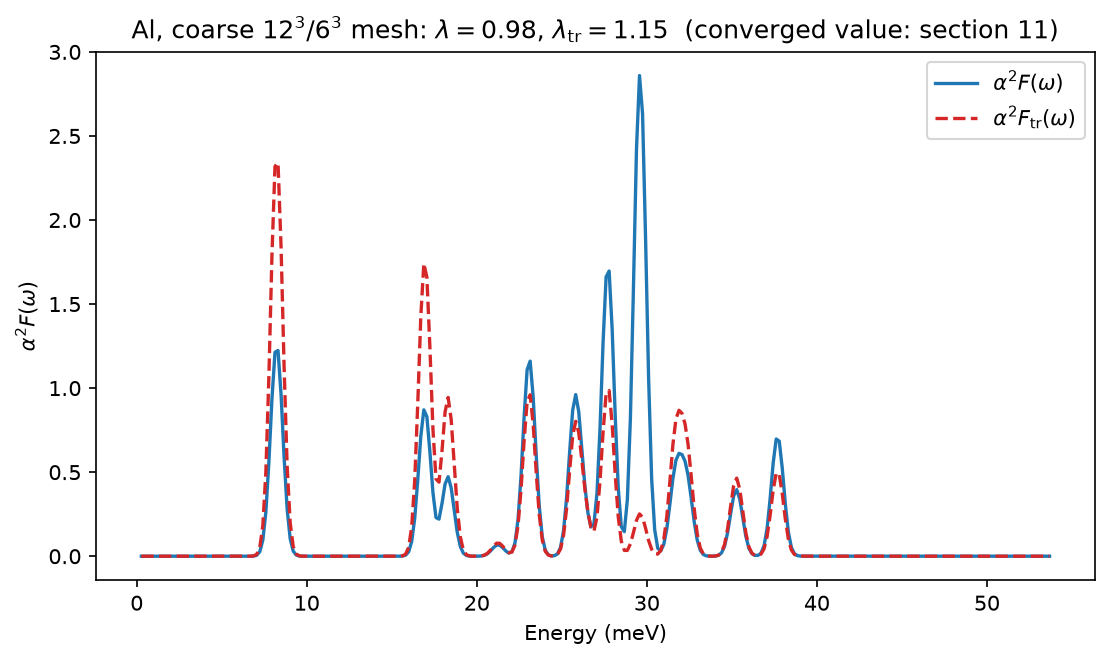

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=150)
omega_mev = omega_grid * HARTREE_TO_EV * 1000
ax.plot(omega_mev, a2f, color='C0', lw=1.6, label=r'$\alpha^2F(\omega)$')
ax.plot(omega_mev, a2f_tr, color='C3', lw=1.6, ls='--', label=r'$\alpha^2F_\mathrm{tr}(\omega)$')
ax.set_xlabel('Energy (meV)'); ax.set_ylabel(r'$\alpha^2F(\omega)$')
ax.set_title(f'Al, coarse $12^3/6^3$ mesh: $\\lambda={lam:.2f}$, '
             f'$\\lambda_\\mathrm{{tr}}={lam_tr:.2f}$  (converged value: section 11)')
ax.legend(); plt.tight_layout(); plt.show()

### 10. Running $\lambda(\omega)$ and $\omega_\mathrm{log}(\omega)$

The cumulative-in-frequency versions of the same two integrals (`analysis.elph.eliashberg_moments`) -- $\lambda(\omega\to\infty)$ recovers the single $\lambda$ number above; $\omega_\mathrm{log}(\omega\to\infty)$ is the Allen-Dynes logarithmic-average phonon frequency, the other ingredient (with $\lambda$) the McMillan-Allen-Dynes $T_c$ formula needs. Plotting both as a function of the upper cutoff shows which part of the phonon spectrum dominates the coupling.

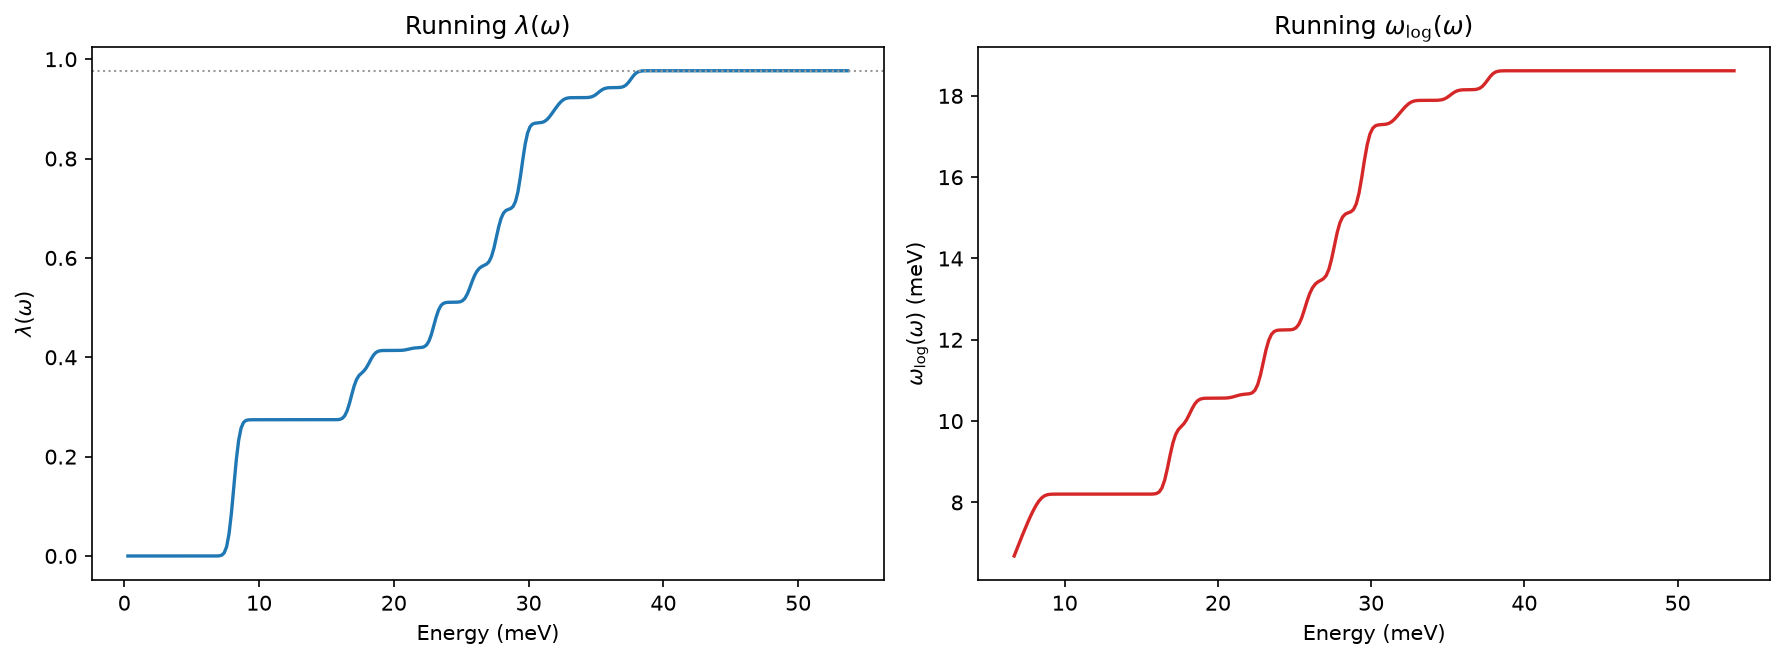

omega_log = 18.62 meV = 150.2 cm^-1
omega_2   = 23.20 meV   (omega_log = 18.62 meV, ratio 1.246)
Allen-Dynes Tc (mu*=0.1): 15.46 K   -- COARSE-MESH estimate; the converged one is section 11
  ... the bare McMillan form (f1=f2=1 dropped) would give 15.21 K


In [12]:
lambda_cum, omega_log_cum = elph.eliashberg_moments(a2f, omega_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
ax1.plot(omega_mev, lambda_cum, color='C0', lw=1.6)
ax1.axhline(lam, color='0.6', ls=':', lw=1)
ax1.set_xlabel('Energy (meV)'); ax1.set_ylabel(r'$\lambda(\omega)$')
ax1.set_title(r'Running $\lambda(\omega)$')

ax2.plot(omega_mev, omega_log_cum * HARTREE_TO_EV * 1000, color='C3', lw=1.6)
ax2.set_xlabel('Energy (meV)'); ax2.set_ylabel(r'$\omega_\mathrm{log}(\omega)$ (meV)')
ax2.set_title(r'Running $\omega_\mathrm{log}(\omega)$')
plt.tight_layout(); plt.show()

omega_log_final = omega_log_cum[-1]
omega_log_cm1 = omega_log_final / CM1_TO_HARTREE
print(f'omega_log = {omega_log_final * HARTREE_TO_EV * 1000:.2f} meV = {omega_log_cm1:.1f} cm^-1')

# Allen-Dynes proper, not the bare McMillan exponential this cell used to
# inline. Two corrections were missing, and both raise Tc:
#   f1 = [1 + (lambda/L1)^{3/2}]^{1/3}          strong coupling
#   f2 = 1 + (w2/wlog - 1) lambda^2/(lambda^2 + L2^2)   spectral shape
# f2 needs the SECOND MOMENT w2 = sqrt((2/lambda) int a2F(w) w dw), which the
# old inline formula never computed. `allen_dynes_tc_from_a2f` derives lambda,
# omega_log and omega_2 from alpha2F together so none can be dropped by
# accident. Negligible for Al (lambda ~ 0.5) but several per cent by MgB2.
from waw.units import K_B_HARTREE
mu_star = 0.1
tc_ha, lam_ad, wlog_ad, w2_ad = elph.allen_dynes_tc_from_a2f(a2f, omega_grid, mu_star)
print(f'omega_2   = {w2_ad * HARTREE_TO_EV * 1000:.2f} meV'
      f'   (omega_log = {wlog_ad * HARTREE_TO_EV * 1000:.2f} meV,'
      f' ratio {w2_ad / wlog_ad:.3f})')
print(f'Allen-Dynes Tc (mu*={mu_star}): {tc_ha / K_B_HARTREE:.2f} K'
      f'   -- COARSE-MESH estimate; the converged one is section 11')
plain = elph.allen_dynes_tc(lam_ad, wlog_ad, wlog_ad, mu_star)   # omega_2=omega_log -> f2=1
print(f'  ... the bare McMillan form (f1=f2=1 dropped) would give '
      f'{plain / K_B_HARTREE:.2f} K')

### 11. Fine-mesh convergence: the proper $\lambda$, $\omega_\mathrm{log}$ and $T_c$

$\lambda$ is the slowest-converging el-ph quantity: a *simultaneous* double Fermi-surface $\delta$-integral, badly under-sampled on the coarse ab-initio mesh above. EPW's fix (the `nkf`/`nqf` fine grids) is native here — $g(\mathbf R_e,\mathbf R_q)$ and $H(\mathbf R)$ are real-space, so `elph.alpha2f(..., hr=hr)` interpolates $H(\mathbf k+\mathbf q)$, the phonons and $g(\mathbf k,\mathbf q)$ onto arbitrarily dense, independent meshes. Three ingredients make dense meshes affordable and the answer well-conditioned (this summation machinery is certified against EPW itself: fed EPW's own Wannier-space vertex on an identical $12^3$ mesh it reproduces EPW's $\lambda$ to $2\times10^{-5}$ and per-q $\lambda_{\mathbf q\nu}$ to 0.015% rms):

1. **Fermi window** (`fsthick`, EPW's own trick): every term carries $e^{-(\epsilon-\epsilon_F)^2/2\sigma^2}$ from both $\delta$s, so k-points whose bands all sit further than $\gtrsim 9\sigma$ from $\epsilon_F$ contribute below double precision — dropping them is exact and cuts the double sum by the window-to-bandwidth ratio ($\sim$5x per mesh side here).
2. **Irreducible q wedge** (`q_weights` from `interfaces.ase.structure.irreducible_qpoints`): the q-summand is invariant under the point group *provided the k-sum stays over the full mesh*, so only star representatives need evaluating — up to 48x for fcc. Same saving as EPW's `mp_mesh_k`.
3. **Extrapolate the coupling, not $\lambda$.** At fixed smearing, $\lambda = N(\epsilon_F)\cdot 2\langle\!\langle|g|^2/\omega\rangle\!\rangle$ factorises into a smooth double-Fermi-surface *average* and a sampling-noise-dominated $N(\epsilon_F)$; fitting $\lambda(N)$ directly extrapolates the noise (`lambda_richardson`'s docstring quantifies this on measured data). So: extrapolate the average over the g-carrying meshes, converge $N(\epsilon_F)$ separately on much denser $H(\mathbf k)$-only meshes (they cost nothing), and multiply at the end.

$\omega_\mathrm{log}$ and $\omega_2$ are *ratios* of $\alpha^2F$ integrals — the noisy $N(\epsilon_F)$ normalisation cancels — so they are read from the fine meshes directly, with the spread across meshes as the error bar. The final $T_c$ is Allen–Dynes proper ($f_1 f_2$, needing $\omega_2$), quoted for the standard $\mu^*$ range.

In [13]:
# Fine-mesh sweep: FIXED sigma_e (isolates the mesh error), Fermi window,
# irreducible q wedge, per-mesh same-sigma N(eF). Cached: delete
# al_lambda_fine.npz to re-run (~2-3 h at 16 threads, 32^3 dominating).
from waw.interfaces.ase.structure import irreducible_qpoints

def phonon_fn(qf):
    b = interpolate_phonons(fc_data, real_lat, np.zeros((1, 3)), qf)
    return CM1_TO_HARTREE * b.freq_cm1, b.eigvecs

FSTHICK = 12.0 * SIGMA_E + omega_ph_q.max()   # >= 12 sigma: window error < 1e-31
FINE = [(16,) * 3, (20,) * 3, (24,) * 3, (28,) * 3, (32,) * 3]
LAMBDA_CACHE = WORK / 'al_lambda_fine.npz'
if not LAMBDA_CACHE.exists():
    rows, a2f_fine = [], []
    for mesh in FINE:
        kf = monkhorst_pack(mesh)
        q_irr, q_w = irreducible_qpoints(atoms, mesh)
        eig_f, U_f = elph.band_eigensystem(hr, kf)
        om_f, ev_f = phonon_fn(q_irr)
        n_ef = elph.fermi_surface_dos(eig_f, EF_MODEL, SIGMA_E)
        a2f_f, lam_qnu = elph.alpha2f(
            eig_f, U_f, g_R, R_e, degen_e, R_q, degen_q, kf, q_irr, None,
            om_f, ev_f, masses_amu, types,
            fermi_energy=EF_MODEL, dos_at_ef=n_ef, omega_grid=omega_grid,
            sigma_e=SIGMA_E, hr=hr, fsthick=FSTHICK, q_weights=q_w,
            return_qnu=True,
        )
        # the grid-free direct sum (EPW's own headline "lambda :"), immune to
        # the omega-grid/phonon-smearing discretisation of the a2f curve
        lam_f = float((q_w[:, None] * np.clip(lam_qnu, 0.0, None)).sum())
        _, wlog_cum = elph.eliashberg_moments(a2f_f, omega_grid)
        w2_f = elph.eliashberg_omega_2(a2f_f, omega_grid)
        rows.append((mesh[0], lam_f, n_ef, wlog_cum[-1], w2_f))
        a2f_fine.append(a2f_f)
        print(f'  {mesh[0]}^3: nq_irr={len(q_irr):4d}  N(eF)={n_ef:7.4f} Ha^-1  '
              f'lambda={lam_f:.4f}  coupling={lam_f / n_ef:.4f}  '
              f'wlog={wlog_cum[-1] * HARTREE_TO_EV * 1e3:5.2f} meV', flush=True)
    rows = np.array(rows)
    # N(eF) on its own, much denser H(k)-only sequence (no g, no phonons)
    dos_rows = []
    for n in (64, 96, 128, 160, 192):
        e_d, _ = elph.band_eigensystem(hr, monkhorst_pack((n,) * 3))
        dos_rows.append((n, elph.fermi_surface_dos(e_d, EF_MODEL, SIGMA_E)))
        print(f'  [dos] {n}^3: N(eF) = {dos_rows[-1][1]:.5f} Ha^-1', flush=True)
    dos_rows = np.array(dos_rows)
    np.savez(LAMBDA_CACHE, rows=rows, dos_rows=dos_rows,
             a2f_fine=np.array(a2f_fine), omega_grid=omega_grid,
             ef_model=EF_MODEL, sigma_e=SIGMA_E, fsthick=FSTHICK)
_z = np.load(LAMBDA_CACHE)
rows, dos_rows, a2f_fine = _z['rows'], _z['dos_rows'], _z['a2f_fine']
for n, l, nef, wl, w2 in rows:
    print(f'  {int(n):2d}^3  N(eF)={nef:7.4f}  lambda={l:.4f}  '
          f'coupling={l / nef:.4f}  wlog={wl * HARTREE_TO_EV * 1e3:5.2f} meV')

  16^3  N(eF)= 3.9299  lambda=0.3286  coupling=0.0836  wlog=28.31 meV
  20^3  N(eF)= 4.6833  lambda=0.3929  coupling=0.0839  wlog=21.33 meV
  24^3  N(eF)= 7.0915  lambda=0.5945  coupling=0.0838  wlog=22.15 meV
  28^3  N(eF)= 6.4842  lambda=0.5535  coupling=0.0854  wlog=23.89 meV
  32^3  N(eF)= 5.1687  lambda=0.4200  coupling=0.0813  wlog=21.84 meV


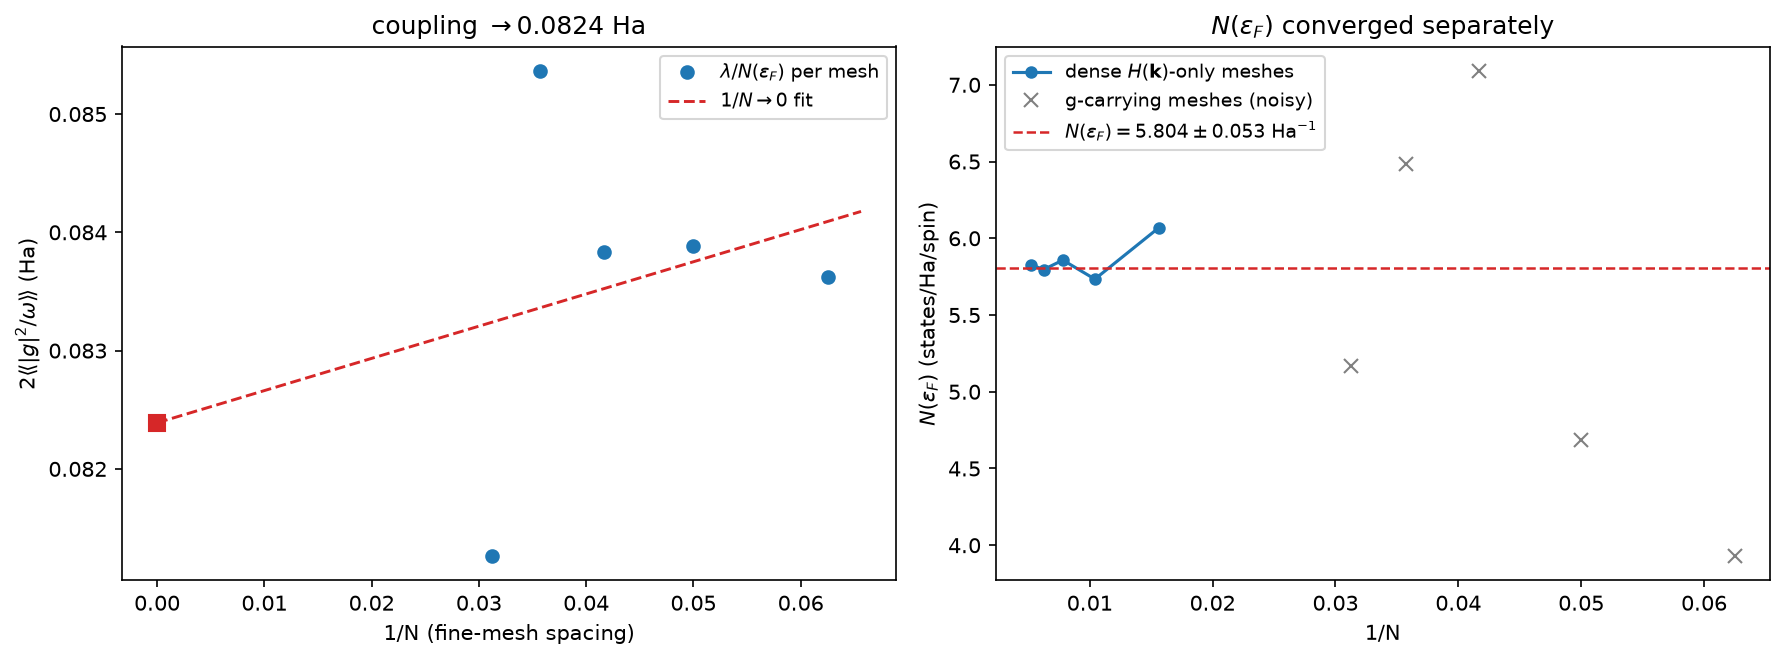

lambda      = 0.4782 +- 0.0094   (coarse 12^3/6^3 gave 0.9767; Al literature 0.4-0.45)
omega_log   = 22.63 +- 1.11 meV   [QE elphsum on this system: ~27 meV]
omega_2     = 27.75 meV   (shape ratio 1.227)
Allen-Dynes Tc(mu*=0.10) = 2.71 K
Allen-Dynes Tc(mu*=0.11) = 2.29 K
Allen-Dynes Tc(mu*=0.13) = 1.56 K
[Al experiment: Tc = 1.18 K]


In [14]:
# Two-stage extrapolation and the final numbers.
Ns, lam_N, nef_N, wlog_N, w2_N = rows.T
coupling = lam_N / nef_N                     # 2<<|g|^2/omega>>, DOS-independent
h = 1.0 / Ns
cslope, rho_inf = np.polyfit(h, coupling, 1)
resid = coupling - (rho_inf + cslope * h)
# N(eF): at these densities the dense H(k)-only sequence has NO residual 1/N
# trend left -- it fluctuates around its converged value -- so a straight-line
# intercept just extrapolates the noise (it landed BELOW every data point).
# The honest estimator is the mean +- std of the densest meshes.
nef_inf = float(dos_rows[1:, 1].mean())
nef_err = float(dos_rows[1:, 1].std(ddof=1))

lam_star = rho_inf * nef_inf
lam_err = float(np.sqrt((np.std(resid, ddof=1) * nef_inf) ** 2
                        + (rho_inf * nef_err) ** 2))
wlog = float(np.mean(wlog_N[-3:])); wlog_err = float(np.std(wlog_N[-3:], ddof=1))
w2 = float(np.mean(w2_N[-3:]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
hh = np.linspace(0, h.max() * 1.05, 50)
ax1.plot(h, coupling, 'o', color='C0', ms=6, label=r'$\lambda/N(\epsilon_F)$ per mesh')
ax1.plot(hh, rho_inf + cslope * hh, '--', color='C3', lw=1.4, label=r'$1/N\to0$ fit')
ax1.plot(0, rho_inf, 's', color='C3', ms=8)
ax1.set_xlabel('1/N (fine-mesh spacing)')
ax1.set_ylabel(r'$2\langle\!\langle|g|^2/\omega\rangle\!\rangle$ (Ha)')
ax1.set_title(rf'coupling $\to{rho_inf:.4f}$ Ha'); ax1.legend(fontsize=9)
ax2.plot(1.0 / dos_rows[:, 0], dos_rows[:, 1], 'o-', color='C0', ms=5,
         label=r'dense $H(\mathbf{k})$-only meshes')
ax2.plot(h, nef_N, 'x', color='0.5', ms=7, label='g-carrying meshes (noisy)')
ax2.axhline(nef_inf, color='C3', lw=1.2, ls='--',
            label=rf'$N(\epsilon_F)={nef_inf:.3f}\pm{nef_err:.3f}$ Ha$^{{-1}}$')
ax2.set_xlabel('1/N'); ax2.set_ylabel(r'$N(\epsilon_F)$ (states/Ha/spin)')
ax2.set_title(r'$N(\epsilon_F)$ converged separately'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

from waw.units import K_B_HARTREE
print(f'lambda      = {lam_star:.4f} +- {lam_err:.4f}   '
      f'(coarse 12^3/6^3 gave {lam:.4f}; Al literature 0.4-0.45)')
print(f'omega_log   = {wlog * HARTREE_TO_EV * 1e3:.2f} +- {wlog_err * HARTREE_TO_EV * 1e3:.2f} meV   '
      f'[QE elphsum on this system: ~27 meV]')
print(f'omega_2     = {w2 * HARTREE_TO_EV * 1e3:.2f} meV   (shape ratio {w2 / wlog:.3f})')
for mu_star in (0.10, 0.11, 0.13):
    tc = elph.allen_dynes_tc(lam_star, wlog, w2, mu_star)
    print(f'Allen-Dynes Tc(mu*={mu_star:.2f}) = {tc / K_B_HARTREE:.2f} K')
print('[Al experiment: Tc = 1.18 K]')

### 12. Doubling the *ab-initio* meshes: 20³ k / 10³ q

Everything above rests on one coarse ab-initio calculation ($12^3$ k, $6^3$ q)
that the fine meshes only *interpolate*. Section 11's error budget named the
$6^3$ dvscf/phonon mesh as the leading remaining uncertainty, so the honest
test is to redo the expensive half at $20^3$ k / $10^3$ q — 47 irreducible
q-points instead of 16, 8000 k-points of `UNK` wavefunctions (24 GB of
$u_{n\mathbf k}$), and a $g(\mathbf R_e,\mathbf R_q)$ built over
$1000\,\mathbf q\times8000\,\mathbf k$ — then push the fine-mesh ladder to
$40^3$. That is a 25.7 h single-shot pipeline, far too heavy for a notebook
cell, so it runs standalone (`data/al_dense_20_10_pipeline.py`,
timings in its log) and this section loads its cached result.

**It moves $\lambda$ by 10% and $T_c$ by a factor of 2.4**, both toward
experiment. The coarse-mesh interpolation was overestimating the coupling, and
the reason is visible in the $\alpha^2F$ overlay below: on the $6^3$ q-mesh the
near-$\Gamma$ acoustic branch is represented by very few q-points, and the
$\lambda\sim|g|^2/\omega^2$ weight there is exactly where a sparse acoustic
representation does the most damage. This is the artifact section 8 warned
about, now quantified rather than just flagged.

In [ ]:
# Cached result of the 20^3 k / 10^3 q pipeline (see the markdown above).
_dense = np.load(HERE / 'data' / 'al_dense_20_10_result.npz')
_rows, _dos_rows = _dense['rows'], _dense['dos_rows']
_a2f_d, _og_d, _EF_d = _dense['a2f_fine'], _dense['og'], float(_dense['EF'])

# Same two-stage estimator as section 11, so the two runs are comparable:
# extrapolate the DOS-independent coupling in 1/N, converge N(eF) separately.
_Ns, _lam_N, _nef_N, _wlog_N, _w2_N = _rows.T
_coup = _lam_N / _nef_N
_cs, _rho_inf = np.polyfit(1.0 / _Ns, _coup, 1)
_resid = _coup - (_rho_inf + _cs / _Ns)
_nef_inf = float(_dos_rows[1:, 1].mean()); _nef_err = float(_dos_rows[1:, 1].std(ddof=1))
_lam_d = _rho_inf * _nef_inf
_lam_d_err = float(np.sqrt((np.std(_resid, ddof=1) * _nef_inf) ** 2
                          + (_rho_inf * _nef_err) ** 2))
_wlog_d = float(np.mean(_wlog_N[-3:])); _wlog_d_err = float(np.std(_wlog_N[-3:], ddof=1))
_w2_d = float(np.mean(_w2_N[-3:]))

print(f'{"":22s}  12^3 k / 6^3 q      20^3 k / 10^3 q     Al reference')
print(f'{"lambda":22s}  {lam_star:.4f} +- {lam_err:.4f}    '
      f'{_lam_d:.4f} +- {_lam_d_err:.4f}    0.40-0.45')
_meV = HARTREE_TO_EV * 1e3           # nb13 keeps wlog/w2 in Hartree
print(f'{"omega_log (meV)":22s}  {wlog * _meV:5.2f} +- {wlog_err * _meV:.2f}      '
      f'{_wlog_d * _meV:5.2f} +- {_wlog_d_err * _meV:.2f}       ~27 (QE elphsum)')
print(f'{"omega_2 (meV)":22s}  {w2 * _meV:5.2f}             {_w2_d * _meV:5.2f}')
print(f'{"N(eF) (1/Ha/spin)":22s}  {nef_inf:5.3f}             {_nef_inf:5.3f}')
print(f'{"fine mesh reached":22s}  32^3               40^3')
for _mu in (0.10, 0.11, 0.12, 0.13):
    _tc_c = elph.allen_dynes_tc(lam_star, wlog, w2, _mu) / K_B_HARTREE
    _tc_d = elph.allen_dynes_tc(_lam_d, _wlog_d, _w2_d, _mu) / K_B_HARTREE
    print(f'  Tc(mu*={_mu:.2f}) [K]        {_tc_c:5.2f}              {_tc_d:5.2f}'
          + ('              1.18 (expt)' if abs(_mu - 0.12) < 1e-9 else ''))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
ax1.plot(omega_mev, a2f, color='0.6', lw=1.4, label=r'ab-initio $12^3/6^3$, fine $32^3$')
ax1.plot(_og_d * _meV, _a2f_d[-1], color='C0', lw=1.6,
         label=r'ab-initio $20^3/10^3$, fine $40^3$')
ax1.set_xlabel('Energy (meV)'); ax1.set_ylabel(r'$\alpha^2F(\omega)$')
ax1.set_title(r'Denser ab-initio q-mesh trims the low-$\omega$ acoustic weight')
ax1.legend(fontsize=9)

ax2.plot(1.0 / Ns, lam_N / nef_N, 'o--', color='0.6', ms=5, label=r'$12^3/6^3$')
ax2.plot(1.0 / _Ns, _coup, 'o-', color='C0', ms=5, label=r'$20^3/10^3$')
ax2.plot(0, _rho_inf, 's', color='C3', ms=8, label=r'$1/N\to0$')
ax2.set_xlabel('1/N (fine-mesh spacing)')
ax2.set_ylabel(r'$2\langle\!\langle|g|^2/\omega\rangle\!\rangle$ (Ha)')
ax2.set_title('DOS-independent coupling, both ab-initio meshes'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Honest scope.** The *summation machinery* behind section 11 is no longer a source of uncertainty: fed EPW's own Wannier-space data (its `epwdata.fmt` Hamiltonian, `epmatwp` vertex and `rdw` dynamical matrices, read by `waw/interfaces/epw/`) on an identical $12^3$ mesh, it reproduces EPW's $\lambda$ to $2\times10^{-5}$ relative and every one of EPW's 1728 per-q $\lambda_{\mathbf q\nu}$ stdout values to 0.015% rms — i.e. to EPW's own print precision (`tests/test_interfaces_epw.py` pins this). What limits the numbers above is therefore the *data*: (i) the reconstructed vertex — pointwise $|g|$ agrees with EPW's `prtgkk` to 1–5% (ordinary reconstruction error: grid, KB projectors, `ph.x` convergence; NOT a missing NLCC term), which enters $\lambda$ quadratically as a few-per-cent-level uncertainty; (ii) the residual $1/N\to0$ extrapolation error of the coupling and of $N(\epsilon_F)$, both quoted; and (iii) the $6^3$ coarse phonon/dvscf q-mesh underlying the interpolation, whose near-$\Gamma$ acoustic representation is the known weak spot of any Wannier-interpolated el-ph calculation (watch the low-$\omega$ tail of $\alpha^2F$ — weight piling up there on the fine meshes that is absent on the ab-initio mesh is an interpolation artifact, not physics). $T_c$ inherits everything exponentially through $\lambda$: at Al's coupling a $\pm0.03$ shift in $\lambda$ moves $T_c$ by $\sim$30%, while $\omega_\mathrm{log}$ enters only linearly — any error budget aimed at $T_c$ is a budget on $\lambda$, and the honest statement of accuracy for this pipeline is the $\lambda$ error bar above, not the $T_c$ digit count.

## Takeaway

A working, native (EPW-free) electron-phonon pipeline, end to end on real DFT data, now **certified against EPW at the machinery level** (waw's $\alpha^2F$ sum on EPW's own Wannier-space vertex reproduces EPW's $\lambda$ to $2\times10^{-5}$ and per-q $\lambda_{\mathbf q\nu}$ to print precision) and cross-validated at the matrix-element level (pointwise $|g|$ to 1–5% against `prtgkk`): raw `dvscf` reading (`interfaces.quantum_espresso.dvscf_io`, bypassing `ph.x`'s own crashing `electron_phonon='Wannier'` feature), the FULL bare+induced perturbation (bare local gradient and nonlocal Kleinman–Bylander derivative reconstructed from the UPF itself — `dvscf` alone is induced-only and 1.5–2x wrong for Al), the Bloch matrix element from UNK wavefunctions with the umklapp $e^{-i\mathbf G\cdot\mathbf r}$ phase for folded $\mathbf k+\mathbf q$, a double real-space Wannier transform (electron and phonon meshes allowed to differ), conversion to genuine phonon-normal-mode coupling with EPW-style acoustic-mode skipping, and $\alpha^2F(\omega)$ for both superconductivity and transport.

Section 11 turns that into a *converged, error-barred* answer: the fine-mesh double-delta sums with EPW's own efficiency tricks (Fermi window, irreducible q wedge), the model's own electron-count Fermi level, the ill-conditioning of the direct $\lambda(N)$ fit resolved by extrapolating the DOS-independent coupling and converging $N(\epsilon_F)$ separately, and an Allen–Dynes $T_c$ (with the $f_1 f_2$ strong-coupling/shape factors and the $\omega_2$ moment they require) quoted over the standard $\mu^*$ range against Al's experimental 1.18 K.

**Next step, for a future session**: a second material (multiple atoms/masses) to exercise the structure factors and per-atom projector bookkeeping end-to-end — the MgB₂ $\sigma/\pi$ two-band notebook (16) is that thread, using the dvscf star rotation (`rotate_dvscf`) so DFPT only runs on the irreducible q wedge.